## Human Activity Recognition (HAR) - Raw Sensor Signals

### Objectif

Construire des réseaux de neurones capables d'identifier l'activité réalisée par une personne à partir des signaux bruts issus des capteurs inertiels d'un smartphone.

### Dataset

Le dataset UCI HAR fournit des séries temporelles multivariées provenant :

- d'un accéléromètre tri-axial
- d'un gyroscope tri-axial

### Format des données

Chaque échantillon est représenté sous la forme :

- **9 canaux** de mesure
- **128 instants temporels**

Format des tenseurs :

- **[9, 128]** pour un échantillon
- **[Batch, 9, 128]** pendant l'entraînement

### Classes à prédire

- Walking
- Walking Upstairs
- Walking Downstairs
- Sitting
- Standing
- Laying

### Approche

1. Chargement et préparation des signaux bruts
2. Implémentation d'une architecture InceptionTime
3. Implémentation d'une architecture ResNet1D
4. Entraînement et évaluation des modèles
5. Comparaison des performances (Accuracy et Cross-Entropy Loss)

In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# CHARGEMENT DES DATAS

def load_raw_signals(dataset_type='train'):
    # Les 9 fichiers bruts
    signals = [
        'body_acc_x_', 'body_acc_y_', 'body_acc_z_',
        'body_gyro_x_', 'body_gyro_y_', 'body_gyro_z_',
        'total_acc_x_', 'total_acc_y_', 'total_acc_z_'
    ]
    loaded_signals = []
    
    print(f"Chargement des signaux bruts pour {dataset_type}...")
    for signal in signals:
        path = f'UCI HAR Dataset/{dataset_type}/Inertial Signals/{signal}{dataset_type}.txt'
        # Lecture du fichier (contient 7352 lignes de 128 valeurs)
        df = pd.read_csv(path, sep=r'\s+', header=None)
        loaded_signals.append(df.values)
    
    # On empile les 9 matrices pour créer notre 3ème dimension (les Channels)
    # axis=1 permet d'avoir le format (Batch, Channels, Time)
    return np.stack(loaded_signals, axis=1)

# Récupération des y datas
extract_folder = "UCI HAR Dataset"
y_train_df = pd.read_csv(f'{extract_folder}/train/y_train.txt', sep=r'\s+', header=None)
y_test_df = pd.read_csv(f'{extract_folder}/test/y_test.txt', sep=r'\s+', header=None)

y_train = torch.tensor(y_train_df.values - 1, dtype=torch.long).squeeze()
y_test = torch.tensor(y_test_df.values - 1, dtype=torch.long).squeeze()

# Création des nouveaux Tensors d'entrée
X_train_raw = torch.tensor(load_raw_signals('train'), dtype=torch.float32)
X_test_raw = torch.tensor(load_raw_signals('test'), dtype=torch.float32)

print(f"Nouvelle forme de X_train : {X_train_raw.shape} -> (Batch, Channels, Time)")

Chargement des signaux bruts pour train...
Chargement des signaux bruts pour test...
Nouvelle forme de X_train : torch.Size([7352, 9, 128]) -> (Batch, Channels, Time)


In [3]:
# CREATION DATAS BATCHS

dataset = TensorDataset(X_train_raw, y_train)                                  # X[i] est associé à y[i]
loader = DataLoader(dataset, batch_size=50, shuffle=True, drop_last=True)      # Contient un X_batch et y_batch

In [4]:
# FONCTION ACCURACY TRAINING

def accuracy(Model):

    Model.eval()      

    correct = 0
    total = 0

    with torch.no_grad():
            
        y_predt = Model(X_test_raw)

        res_pred = y_predt.max(1).indices
        correct += (res_pred == y_test).float().sum()
        total += y_test.size(0)
        
        accuracy = (correct / total)*100
        
        return accuracy

### <u>Architecture Inception</u>

Convolutions en parallèles => Repérer motifs longs et courts

In [16]:
# STRUCTURE DU RESEAU DE NEURONES

class CNN1D_Model(nn.Module):     # Model => héritage de la classe Module 

    def __init__(self):
        super().__init__()      # Appel le constructeur de Module : donne accès aux méthodes (.parameters() / .train() / .eval() / ...)
        
        # ---| PARTIE 1 : Extracteur de Motifs Convolutions |---

        # Couche Conv1 : Lecture des 9 capteurs, X loupes de taille ker_size
        # padding -> rajoute des 0 permettant au kernel d'aller sur les bords => même taille
        self.conv_courte = nn.Conv1d(in_channels=9, out_channels=32, kernel_size=3, padding='same', bias=False)
        self.conv_longue = nn.Conv1d(in_channels=9, out_channels=32, kernel_size=7, padding='same', bias=False)
        # Fusion : 32 + 32 = 64 channels
        self.batchN1 = nn.BatchNorm1d(64)
        
        # Division de la dimension temporelle par le kernel 
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        # Couche Conv 2 : On prend les X motifs trouvés, et on crée Y nouvelles loupes pour les combiner 
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=64, kernel_size=7, bias=False)
        self.batchN2 = nn.BatchNorm1d(64)
        
        # Division de la dimension temporelle par le kernel 
        #self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.gap = nn.AdaptiveAvgPool1d(1)

        # ---| METHODE : DUMMY PASS |---
        
        #dummy_x = torch.zeros(1, 9, 128)
        
        #with torch.no_grad():
        #   x_c = self.conv_courte(dummy_x)
        #    x_l = self.conv_longue(dummy_x)
        #    x_fusion = torch.cat((x_c, x_l), dim=1)
        #    dummy_x = self.pool1(x_fusion)
        #    dummy_x = self.conv2(dummy_x)
        #    dummy_x = self.pool2(dummy_x)
            
        #    self.flatten_size = dummy_x.view(1, -1).size(1)
        
        #print(f"Flatten_size calculé automatiquement : {self.flatten_size}")

        # ---| PARTIE 2 : Classificateur Linéaire |---
            
        #self.fc1 = nn.Linear(self.flatten_size, 256, bias=False)
        self.fc1 = nn.Linear(64, 256, bias=False)
        self.batchNfc1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 64, bias=False) 
        self.batchNfc2 = nn.BatchNorm1d(64)
        self.fc_out = nn.Linear(64, 6)
        self.dropout = nn.Dropout(0.5)


    def forward(self, x):
        
        x_court = self.conv_courte(x)
        x_long = self.conv_longue(x)
        x = torch.cat((x_court, x_long), dim=1)
        x = self.batchN1(x)
        x = F.relu(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.batchN2(x)
        x = F.relu(x)
        #x = self.pool2(x)
        x = self.gap(x)

        # Flatten : bloc 3D [Batch, 64 canaux, _ instants] -> bloc plat (2D) [Batch, instants des canaux à la suite]
        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.batchNfc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        x = self.batchNfc2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc_out(x) 

        return x 

In [17]:
# CREATION DU RESEAU DE NEURONES
mlp_Inception = CNN1D_Model()      

In [18]:
# Training

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_Inception.parameters(), lr=0.001)      

epochs = 150
best_acc = 0

update_ratios = []
steps = []
global_step = 0

for epoch in range(epochs):

    mlp_Inception.train()
    
    for X_batch, y_batch in loader:

        # Foward pass : 
        y_pred = mlp_Inception(X_batch)

        # Loss :
        loss = criterion(y_pred, y_batch)
        if global_step == 0:
            print(f"Premier loss = {loss.item():.4f}")

        # Reset Grad :
        optimizer.zero_grad()

        # Back pass :
        loss.backward()

        #Calcul des weights avant update
        with torch.no_grad():
            weights_before = mlp_Inception.fc2.weight.clone()

        # Update Weights :
        optimizer.step()
    
        # Diagnostique :
        with torch.no_grad():
            global_step +=1
            steps.append(global_step) 

            weights_after = mlp_Inception.fc2.weight
            taille_pas = (weights_after - weights_before).abs().mean()
            update_ratio = torch.log10(taille_pas / weights_after.abs().mean() + 1e-8)
            update_ratios.append(update_ratio)

    # Test après chaque epoch => éviter l'overtraining
    current_acc = accuracy(mlp_Inception)
    print(f"Epoch {epoch:02d} | Loss Train: {loss.item():.4f} | Acc Test: {current_acc:.2f}%")
        
    if best_acc <= current_acc :
        best_acc = current_acc
        torch.save(mlp_Inception.state_dict(), 'best_model_HAR2_In.pth')
          
print(f"Meilleur précision : {best_acc:.2f}")

Premier loss = 1.8589
Epoch 00 | Loss Train: 0.1982 | Acc Test: 88.06%
Epoch 01 | Loss Train: 0.2289 | Acc Test: 92.57%
Epoch 02 | Loss Train: 0.1652 | Acc Test: 84.76%
Epoch 03 | Loss Train: 0.0992 | Acc Test: 93.18%
Epoch 04 | Loss Train: 0.1552 | Acc Test: 92.60%
Epoch 05 | Loss Train: 0.0625 | Acc Test: 92.40%
Epoch 06 | Loss Train: 0.0737 | Acc Test: 92.37%
Epoch 07 | Loss Train: 0.2193 | Acc Test: 91.69%
Epoch 08 | Loss Train: 0.1846 | Acc Test: 92.26%
Epoch 09 | Loss Train: 0.2279 | Acc Test: 92.98%
Epoch 10 | Loss Train: 0.1044 | Acc Test: 92.37%
Epoch 11 | Loss Train: 0.1302 | Acc Test: 92.13%
Epoch 12 | Loss Train: 0.1577 | Acc Test: 93.25%
Epoch 13 | Loss Train: 0.0552 | Acc Test: 92.03%
Epoch 14 | Loss Train: 0.1897 | Acc Test: 92.84%
Epoch 15 | Loss Train: 0.1135 | Acc Test: 92.87%
Epoch 16 | Loss Train: 0.1088 | Acc Test: 86.90%
Epoch 17 | Loss Train: 0.2573 | Acc Test: 92.30%
Epoch 18 | Loss Train: 0.1691 | Acc Test: 92.74%
Epoch 19 | Loss Train: 0.2073 | Acc Test: 93.99

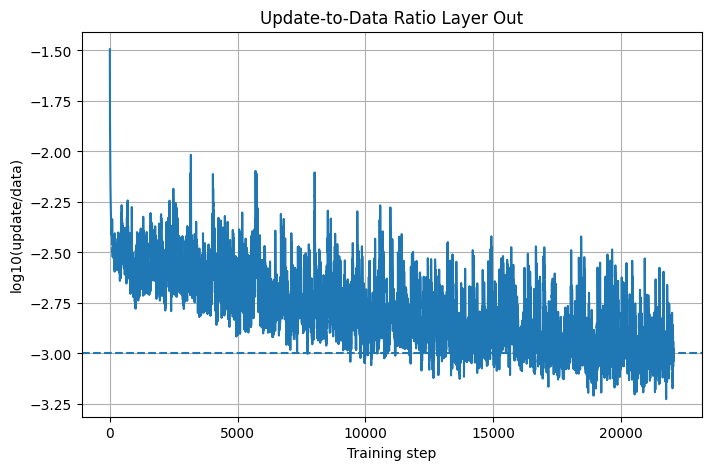

In [19]:
# AFFICHAGE DE L'UPDATE RATIO

plt.figure(figsize=(8,5))
plt.plot(steps, update_ratios)
plt.axhline(-3, linestyle='--')
plt.xlabel("Training step")
plt.ylabel("log10(update/data)")
plt.title("Update-to-Data Ratio Layer Out")
plt.grid(True)
plt.show()

In [20]:
# RECUPERATION DU BEST MODEL

# Étape 1 : Réinstancier l'architecture
best_mlp_Inception = CNN1D_Model()

# Étape 2 : Chargement du dictionnaire de paramètres (disque dur -> VRAM)
paramètres = torch.load('best_model_HAR2_In.pth')

# Étape 3 : Injectes des paramètres dans l'architecture 
best_mlp_Inception.load_state_dict(paramètres)

<All keys matched successfully>

In [21]:
# PHASE DE TEST

best_mlp_Inception.eval()      # BatchNorm1d : running_mean & running_std / Stop Dropout

with torch.no_grad():
    
    y_predt = best_mlp_Inception(X_test_raw)
    loss_test = criterion(y_predt, y_test)
    print(f"Test Loss : {loss_test.item():.6f}")

    res_pred = y_predt.max(1).indices
    acc = (res_pred == y_test).float().mean()
    print(f"Précision sur le Test : {acc.item() * 100:.2f} %")

Test Loss : 0.232774
Précision sur le Test : 94.94 %


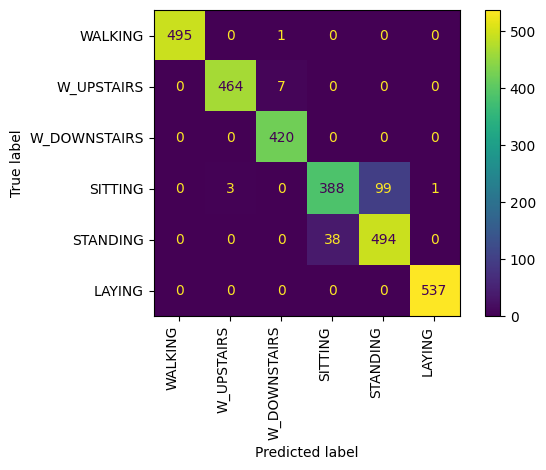

In [22]:
# MATRICE DE CONFUSION

best_mlp_Inception.eval()      

all_pred = []
all_true = []

with torch.no_grad():
      
    y_predt = best_mlp_Inception(X_test_raw)
    pred = y_predt.argmax(dim=1)

    all_pred.extend(pred.numpy())
    all_true.extend(y_test.numpy())

    cm = confusion_matrix(all_true, all_pred, normalize=None)

activity_names = ['WALKING', 'W_UPSTAIRS', 'W_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=activity_names)
disp.plot()

plt.xticks(rotation=90, ha='right')
plt.tight_layout()

plt.show()

### <u>ResNet 1D</u>

CNN 1D classique + skip connections

In [5]:
# STRUCTURE DU RESIDUAL BLOCK

class ResidualBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(channels)

        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(channels)

    def forward(self, x):

        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity        # Permet un meilleur apprentissage => circulation du gradient dans les premières couches 

        out = F.relu(out)

        return out

In [6]:
# STUCTURE DU RESEAU DE NEURONES

class ResNet1D(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=9, out_channels=32, kernel_size=3, padding='same', bias=False)
        self.bn1 = nn.BatchNorm1d(32)

        self.block1 = ResidualBlock(32)
        self.block2 = ResidualBlock(32)

        self.pool = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding='same', bias=False)
        self.bn2 = nn.BatchNorm1d(64)

        self.block3 = ResidualBlock(64)
        self.block4 = ResidualBlock(64)

        self.gap = nn.AdaptiveAvgPool1d(1)      # Moyenne temporelle de tous les éléments au sein d'un canal (nombre moyen d'apparitions d'un motif)

        self.fc_out = nn.Linear(64, 6)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)       # x = x.squeeze(-1) ou x = torch.flatten(x, 1) => retirer la dernière dimension (taille 1)
        x = self.fc_out(x)

        return x


In [7]:
# CREATION DU RESEAU DE NEURONES
mlpRN1d = ResNet1D()

In [8]:
# Training

criterion_ = nn.CrossEntropyLoss()
optimizer_ = optim.Adam(mlpRN1d.parameters(), lr=0.001)      # weight_decay=1e-4 -> contre l'overfitting

epochs_ = 150
best_acc = 0

update_ratios_ = []
steps_ = []
global_step_ = 0

for epoch in range(epochs_):

    mlpRN1d.train()
    
    for X_batch, y_batch in loader:

        # Foward pass : 
        y_pred_ = mlpRN1d(X_batch)

        # Loss :
        loss_ = criterion_(y_pred_, y_batch)
        if global_step_ == 0:
            print(f"Premier loss = {loss_.item():.4f}")

        # Reset Grad :
        optimizer_.zero_grad()

        # Back pass :
        loss_.backward()

        #Calcul des weights avant update
        with torch.no_grad():
            weights_before_ = mlpRN1d.fc_out.weight.clone()

        # Update Weights :
        optimizer_.step()
    
        # Diagnostique :
        with torch.no_grad():
            global_step_ +=1
            steps_.append(global_step_) 

            weights_after_ = mlpRN1d.fc_out.weight
            taille_pas = (weights_after_ - weights_before_).abs().mean()
            update_ratio_ = torch.log10(taille_pas / weights_after_.abs().mean() + 1e-8)
            update_ratios_.append(update_ratio_)

    # Test après chaque epoch => éviter l'overtraining
    current_acc = accuracy(mlpRN1d)
    print(f"Epoch {epoch:02d} | Loss Train: {loss_.item():.4f} | Acc Test: {current_acc:.2f}%")
        
    if best_acc <= current_acc :
        best_acc = current_acc
        torch.save(mlpRN1d.state_dict(), 'best_model_HAR2_Re.pth')
          
print(f"Meilleur précision : {best_acc:.2f}")

Premier loss = 1.9036
Epoch 00 | Loss Train: 0.3002 | Acc Test: 90.53%
Epoch 01 | Loss Train: 0.0665 | Acc Test: 91.96%
Epoch 02 | Loss Train: 0.0624 | Acc Test: 90.16%
Epoch 03 | Loss Train: 0.1499 | Acc Test: 90.53%
Epoch 04 | Loss Train: 0.0660 | Acc Test: 91.69%
Epoch 05 | Loss Train: 0.1650 | Acc Test: 91.48%
Epoch 06 | Loss Train: 0.1643 | Acc Test: 92.33%
Epoch 07 | Loss Train: 0.0701 | Acc Test: 91.69%
Epoch 08 | Loss Train: 0.0358 | Acc Test: 92.33%
Epoch 09 | Loss Train: 0.1045 | Acc Test: 93.72%
Epoch 10 | Loss Train: 0.1043 | Acc Test: 93.48%
Epoch 11 | Loss Train: 0.0920 | Acc Test: 91.92%
Epoch 12 | Loss Train: 0.1103 | Acc Test: 94.10%
Epoch 13 | Loss Train: 0.0763 | Acc Test: 92.53%
Epoch 14 | Loss Train: 0.1027 | Acc Test: 93.11%
Epoch 15 | Loss Train: 0.0836 | Acc Test: 94.40%
Epoch 16 | Loss Train: 0.1391 | Acc Test: 92.09%
Epoch 17 | Loss Train: 0.1668 | Acc Test: 93.15%
Epoch 18 | Loss Train: 0.0725 | Acc Test: 92.94%
Epoch 19 | Loss Train: 0.0748 | Acc Test: 92.47

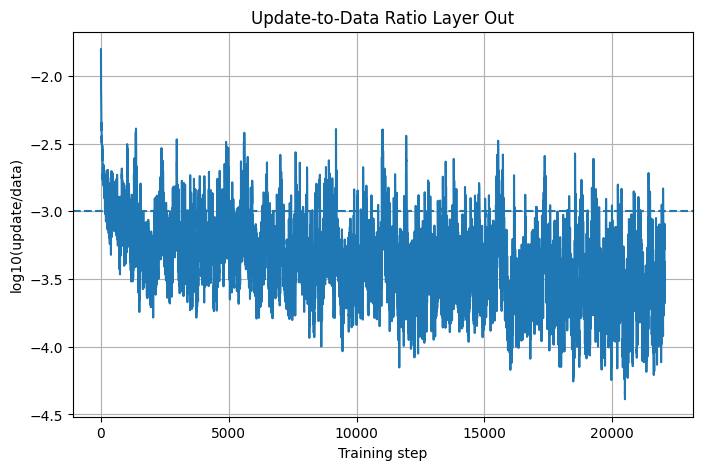

In [9]:
plt.figure(figsize=(8,5))
plt.plot(steps_, update_ratios_)
plt.axhline(-3, linestyle='--')
plt.xlabel("Training step")
plt.ylabel("log10(update/data)")
plt.title("Update-to-Data Ratio Layer Out")
plt.grid(True)
plt.show()

In [10]:
# RECUPERATION DU BEST MODEL

# Étape 1 : Réinstancier l'architecture
best_mlp_ResNet = ResNet1D()

# Étape 2 : Chargement du dictionnaire de paramètres (disque dur -> VRAM)
paramètres = torch.load('best_model_HAR2_Re.pth')

# Étape 3 : Injectes des paramètres dans l'architecture 
best_mlp_ResNet.load_state_dict(paramètres)

<All keys matched successfully>

In [12]:
# Phase de test
best_mlp_ResNet.eval()      # BatchNorm1d : running_mean & running_std / Stop Dropout

with torch.no_grad():
    
    y_predt_ = best_mlp_ResNet(X_test_raw)
    loss_test_ = criterion_(y_predt_, y_test)
    print(f"Test Loss : {loss_test_.item():.6f}")

    res_pred_ = y_predt_.max(1).indices
    acc = (res_pred_ == y_test).float().mean()
    print(f"Précision sur le Test : {acc.item() * 100:.2f} %")

Test Loss : 0.139393
Précision sur le Test : 97.25 %


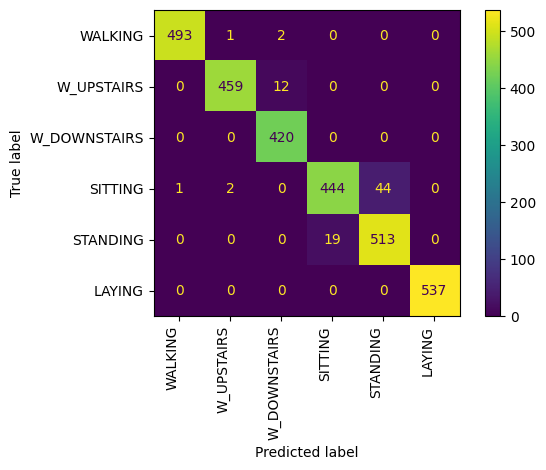

In [13]:
# MATRICE DE CONFUSION

best_mlp_ResNet.eval()      

all_pred = []
all_true = []

with torch.no_grad():
      
    y_predt = best_mlp_ResNet(X_test_raw)
    pred = y_predt.argmax(dim=1)

    all_pred.extend(pred.numpy())
    all_true.extend(y_test.numpy())

    cm = confusion_matrix(all_true, all_pred, normalize=None)

activity_names = ['WALKING', 'W_UPSTAIRS', 'W_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=activity_names)
disp.plot()

plt.xticks(rotation=90, ha='right')
plt.tight_layout()

plt.show()